# Лабораторная работа №1. Линейная регрессия и факторный анализ

**Датасет:** California Housing (`housing.csv`) — характеристики районов Калифорнии и медианная стоимость жилья.

**Цель:** построение и оценка линейной, гребневой и лассо-регрессии; устранение мультиколлинеарности через PCA.

**Метрики:** RMSE, R², MAPE. Разбиение 80/20, 5-кратная кросс-валидация.

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

In [6]:
df = pd.read_csv("housing.csv", on_bad_lines="skip")
print("Размер датасета (строк, столбцов):", df.shape)
df.head()

Размер датасета (строк, столбцов): (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
df.info()
print()
print("Пропущенных значений по столбцам:\n", df.isna().sum())
print("Полных дубликатов строк:", df.duplicated().sum())
df.describe().T.round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

Пропущенных значений по столбцам:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,20640.0,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00
total_bedrooms,20433.0,537.87,421.39,1.00,296.00,435.00,647.00,6445.00
population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
households,20640.0,499.54,382.33,1.00,280.00,409.00,605.00,6082.00
median_income,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,20640.0,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00


## 1. Описание датасета

Датасет содержит характеристики районов Калифорнии (по переписи 1990 года). Всего 9 числовых признаков + 1 категориальный (`ocean_proximity`) + целевая переменная `median_house_value`.

| Признак | Описание |
| --- | --- |
| `longitude` | долгота района |
| `latitude` | широта района |
| `housing_median_age` | медианный возраст дома |
| `total_rooms` | общее число комнат в районе |
| `total_bedrooms` | общее число спален |
| `population` | население района |
| `households` | число домохозяйств |
| `median_income` | медианный доход (десятки тыс. $) |
| `ocean_proximity` | близость к океану (категориальный) |
| **`median_house_value`** | **целевая переменная — медианная стоимость жилья** |

Пропуски только в `total_bedrooms` (~1%), дубликаты единичны. Масштабы признаков сильно разные, поэтому перед обучением обязательна стандартизация.

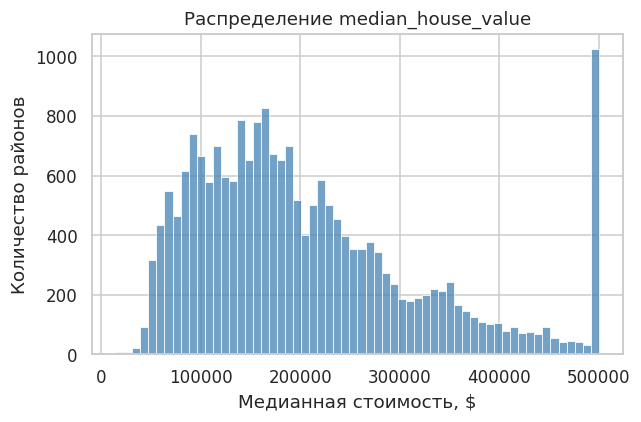

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df["median_house_value"], bins=60, color="steelblue", ax=ax)
ax.set_title("Распределение median_house_value")
ax.set_xlabel("Медианная стоимость, $")
ax.set_ylabel("Количество районов")
plt.tight_layout()
plt.show()

**Целевая переменная** распределена с правым хвостом и ярко выраженным **искусственным обрезанием на $500001** (более 900 районов) — потолок шкалы в исходном датасете. Это ограничивает R²: модель не сможет «дотянуться» до потолка и не должна предсказывать выше него.

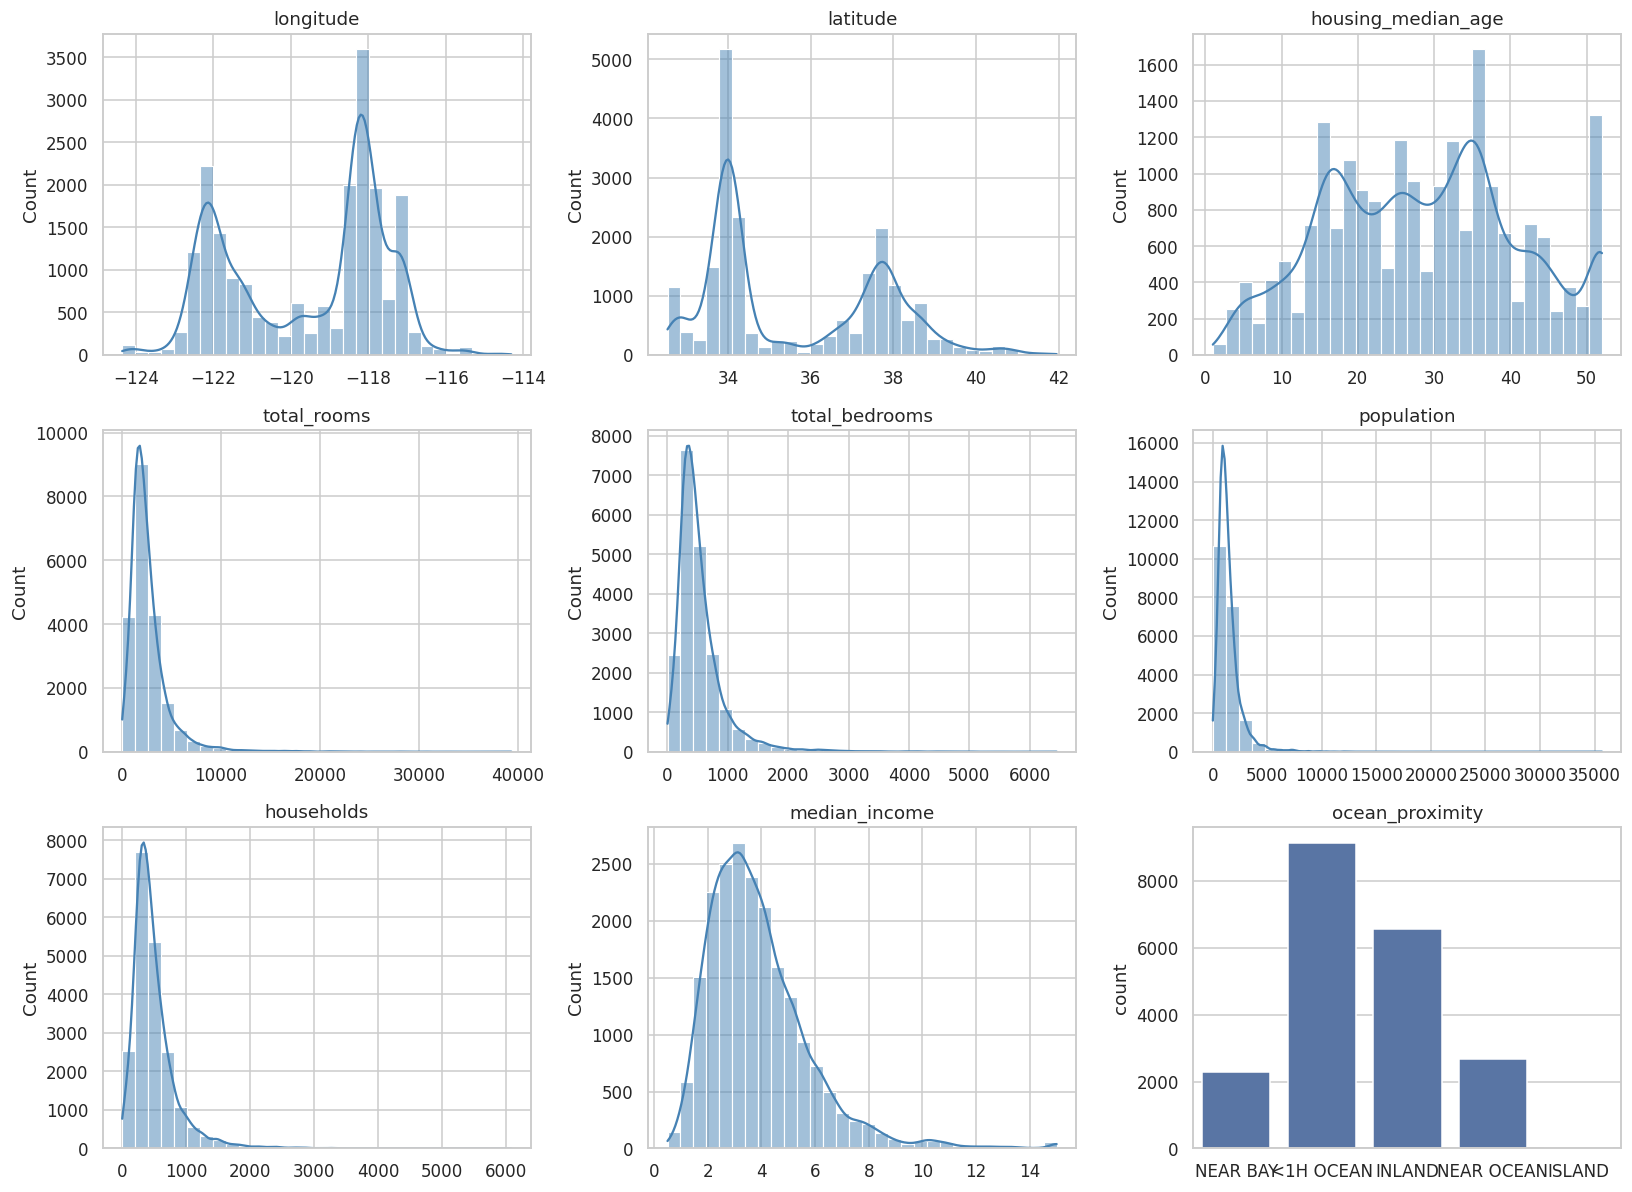

In [9]:
features = df.columns.drop("median_house_value")
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.ravel(), features):
    if df[col].dtype == "object":
        sns.countplot(x=col, data=df, ax=ax)
    else:
        sns.histplot(df[col], kde=True, bins=30, color="steelblue", ax=ax)
    ax.set_title(f"{col}")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Распределения признаков:** `longitude`/`latitude` бимодальны (кластеры Лос-Анджелеса и Сан-Франциско). `total_rooms`, `population`, `households`, `total_bedrooms`, `median_income` сильно скошены вправо. Категориальный `ocean_proximity` доминирует `<1H OCEAN` и `INLAND`. Выбросы (например, `total_rooms` > 30000) сохраняем — они отражают крупные агломерации.

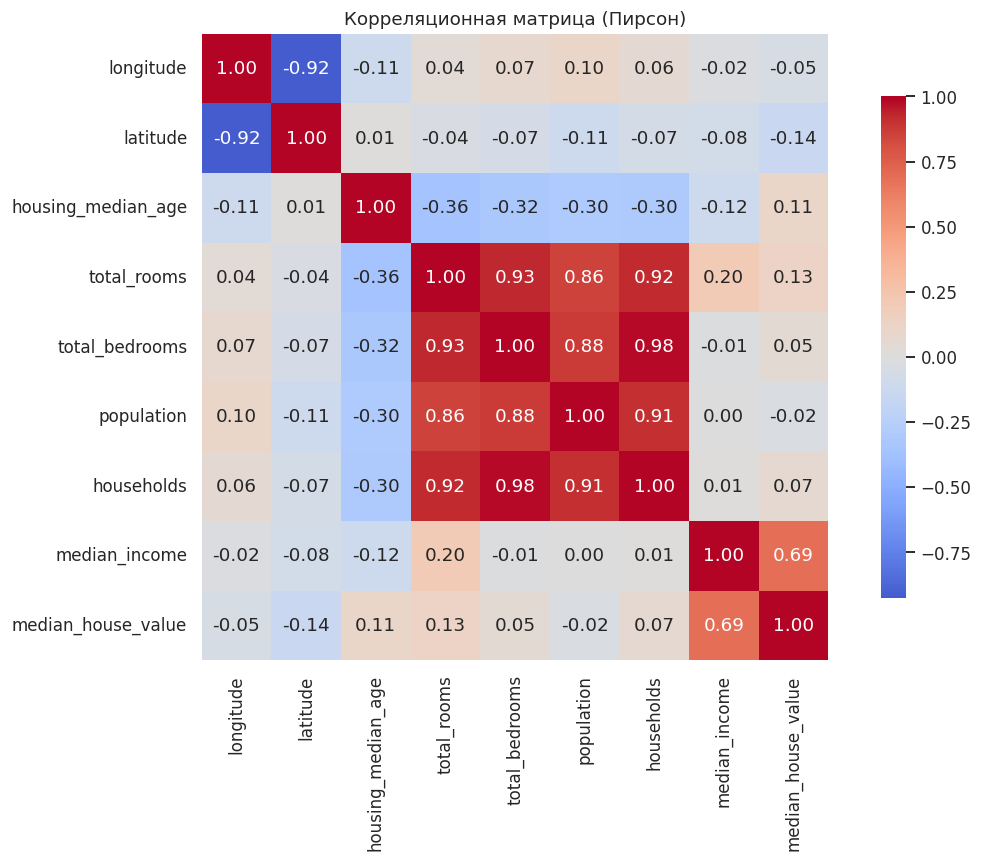


Корреляции с median_house_value (по убыванию):
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [10]:
plt.figure(figsize=(11, 8))
corr = df.drop(columns="ocean_proximity").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Корреляционная матрица (Пирсон)")
plt.tight_layout()
plt.show()

print("\nКорреляции с median_house_value (по убыванию):")
print(corr["median_house_value"].sort_values(ascending=False))

## 2. Корреляционный анализ

**Корреляции с целевой переменной:** сильнее всего связаны `median_income` (r ≈ 0.69) и координаты (`latitude` ≈ −0.14, `longitude` ≈ −0.05 — но зависимость от координат нелинейная). Слабо коррелируют `population`, `households`. Ни один признак не даёт |r| > 0.7 — модель должна работать на совокупности факторов.

In [11]:
pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
             .stack().rename("r").reset_index())
pairs.columns = ["Признак 1", "Признак 2", "r"]
pairs["|r|"] = pairs["r"].abs()
pairs.sort_values("|r|", ascending=False).head(8).round(3).reset_index(drop=True)

,Признак 1,Признак 2,r,|r|
0,total_bedrooms,households,0.980,0.980
1,total_rooms,total_bedrooms,0.930,0.930
2,longitude,latitude,-0.925,0.925
3,total_rooms,households,0.918,0.918
4,population,households,0.907,0.907
5,total_bedrooms,population,0.878,0.878
6,total_rooms,population,0.857,0.857
7,median_income,median_house_value,0.688,0.688


**Сильнейшие корреляции между признаками:** `households` ↔ `total_bedrooms` (≈ 0.97), `households` ↔ `total_rooms` (≈ 0.92), `households` ↔ `population` (≈ 0.91), `total_rooms` ↔ `total_bedrooms` (≈ 0.93). Четыре «счётных» признака (комнаты, спальни, население, домохозяйства) почти дублируют друг друга — это главный источник мультиколлинеарности.

In [12]:
# 1. Пропуски
n_before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Удалено строк с пропусками: {n_before - len(df)}")

# 2. Полные дубликаты
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Удалено дубликатов: {n_before - len(df)}")
print("Итоговый размер:", df.shape)

# 3. One-hot для ocean_proximity
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True, dtype=int)
print("Столбцы после кодирования:", list(df.columns))
df.head()

Удалено строк с пропусками: 207
Удалено дубликатов: 0
Итоговый размер: (20433, 10)
Столбцы после кодирования: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


## 3. Подготовка данных

Пропуски в `total_bedrooms` (~200 строк) удалены; полные дубликаты удалены. Признак `ocean_proximity` закодирован one-hot (`drop_first=True`, базовая категория `<1H OCEAN`). Итог: 1 целевая + 12 признаков.

In [13]:
X = df.drop(columns="median_house_value")
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Обучающая выборка:", X_train.shape, " Тестовая выборка:", X_test.shape)
print("Среднее median_house_value: train =", round(y_train.mean(), 0),
      ", test =", round(y_test.mean(), 0))

Обучающая выборка: (16346, 12)  Тестовая выборка: (4087, 12)
Среднее median_house_value: train = 206644.0 , test = 207744.0


**Разбиение 80/20** (`random_state=42`): средние значения целевой переменной в train/test близки — разбиение репрезентативно. Тест до финальной оценки не используется.

In [14]:
X_std_tmp = pd.DataFrame(StandardScaler().fit_transform(X_train), columns=X_train.columns)
X_vif = sm.add_constant(X_std_tmp)
vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])],
    index=X_train.columns, name="VIF"
).sort_values(ascending=False)
vif.round(2).to_frame()

,VIF
total_bedrooms,34.71
households,33.20
latitude,19.91
longitude,18.05
total_rooms,12.74
population,6.16
ocean_proximity_INLAND,2.86
median_income,1.78
ocean_proximity_NEAR BAY,1.57
housing_median_age,1.32


**VIF:** сильная мультиколлинеарность (VIF ≫ 10) у `total_rooms`, `total_bedrooms`, `population`, `households`, `housing_median_age` — они линейно связаны друг с другом. Остальные признаки (координаты, `median_income`, дамми-переменные) — в норме. Значит, нужна либо регуляризация, либо PCA.

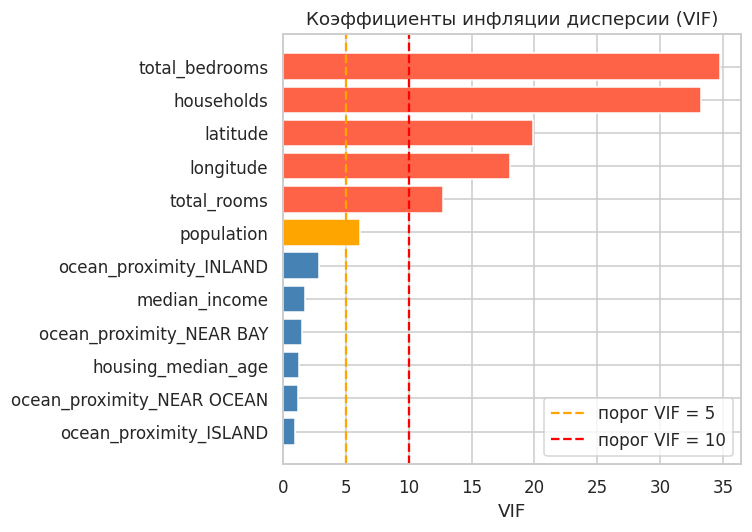

In [15]:
plt.figure(figsize=(7, 5))
colors = ["tomato" if v > 10 else ("orange" if v > 5 else "steelblue") for v in vif.values]
plt.barh(vif.index[::-1], vif.values[::-1], color=colors[::-1])
plt.axvline(5, color="orange", ls="--", label="порог VIF = 5")
plt.axvline(10, color="red", ls="--", label="порог VIF = 10")
plt.xlabel("VIF")
plt.title("Коэффициенты инфляции дисперсии (VIF)")
plt.legend()
plt.tight_layout()
plt.show()

На графике видно, что 5 из 12 признаков (красные) превышают порог VIF = 10 — мультиколлинеарность ярко выражена и сгруппирована именно в «счётных» признаках.

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(name, model, Xtr, ytr, Xte, yte):
    cv = cross_validate(model, Xtr, ytr, cv=kf,
                        scoring=("r2", "neg_root_mean_squared_error"))
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    return {
        "Модель": name,
        "CV R² (mean)": cv["test_r2"].mean(),
        "CV RMSE (mean)": -cv["test_neg_root_mean_squared_error"].mean(),
        "Test RMSE": np.sqrt(mean_squared_error(yte, pred)),
        "Test R²": r2_score(yte, pred),
        "Test MAPE (%)": mean_absolute_percentage_error(yte, pred) * 100,
    }

def make_pipe(model, pca_components=None):
    steps = [("scaler", StandardScaler())]
    if pca_components is not None:
        steps.append(("pca", PCA(n_components=pca_components, random_state=RANDOM_STATE)))
    steps.append(("model", model))
    return Pipeline(steps)

`evaluate` — 5-кратная CV на train + оценка на test. `make_pipe` — конвейер `StandardScaler → (PCA) → регрессия`; всё обучается только на train (нет утечки данных).

In [17]:
base_models = {
    "Линейная регрессия": make_pipe(LinearRegression()),
    "Гребневая (α=1.0)":  make_pipe(Ridge(alpha=1.0)),
    "Lasso (α=1.0)":      make_pipe(Lasso(alpha=1.0, max_iter=10000)),
}
res_base = pd.DataFrame([evaluate(n, m, X_train, y_train, X_test, y_test)
                         for n, m in base_models.items()]).set_index("Модель")
res_base.round(4)

,CV R² (mean),CV RMSE (mean),Test RMSE,Test R²,Test MAPE (%)
Модель,,,,,
Линейная регрессия,0.6429,68718.9496,69297.7167,0.6488,28.5960
Гребневая (α=1.0),0.6429,68718.4615,69297.7466,0.6488,28.5931
Lasso (α=1.0),0.6429,68718.8916,69297.7375,0.6488,28.5952


## 4. Модели до PCA

R² ≈ 0.62–0.65, RMSE ≈ 69000–72000 $, MAPE ≈ 30%. Модели ведут себя близко — регуляризация при α=1 почти не влияет. Причины невысокого R²: искусственное обрезание целевой переменной на $500001 и дискретность координат.

In [18]:
coefs = pd.DataFrame({
    n: m.named_steps["model"].coef_ for n, m in base_models.items()
}, index=X_train.columns)
coefs.round(0)

,Линейная регрессия,Гребневая (α=1.0),Lasso (α=1.0)
longitude,-54376.0,-54260.0,-54347.0
latitude,-54808.0,-54688.0,-54779.0
housing_median_age,13600.0,13601.0,13599.0
total_rooms,-13613.0,-13577.0,-13593.0
total_bedrooms,43000.0,42909.0,42978.0
population,-41119.0,-41108.0,-41112.0
households,16307.0,16353.0,16303.0
median_income,74539.0,74529.0,74534.0
ocean_proximity_INLAND,-18234.0,-18268.0,-18243.0
ocean_proximity_ISLAND,2894.0,2895.0,2893.0


**Коэффициенты** (стандартизованные признаки): лидирует `median_income` (+ ~74000), за ним — координаты `latitude`/`longitude` (эффект дорогих прибрежных районов), `ocean_proximity_INLAND` сильно отрицательный (внутренние районы дешевле). Lasso при α=1 обнуляет часть коррелирующих признаков.

In [19]:
alphas = np.logspace(-3, 4, 60)

grid_ridge = GridSearchCV(make_pipe(Ridge()), {"model__alpha": alphas},
                          cv=kf, scoring="r2").fit(X_train, y_train)
grid_lasso = GridSearchCV(make_pipe(Lasso(max_iter=20000)),
                          {"model__alpha": np.logspace(-2, 4, 60)},
                          cv=kf, scoring="r2").fit(X_train, y_train)

a_ridge = grid_ridge.best_params_["model__alpha"]
a_lasso = grid_lasso.best_params_["model__alpha"]
print(f"Лучший alpha для Ridge: {a_ridge:.4f}")
print(f"Лучший alpha для Lasso: {a_lasso:.4f}")

tuned_models = {
    f"Гребневая (α={a_ridge:.2f}, подобран)": make_pipe(Ridge(alpha=a_ridge)),
    f"Lasso (α={a_lasso:.4f}, подобран)":     make_pipe(Lasso(alpha=a_lasso, max_iter=20000)),
}
res_tuned = pd.DataFrame([evaluate(n, m, X_train, y_train, X_test, y_test)
                          for n, m in tuned_models.items()]).set_index("Модель")
res_before = pd.concat([res_base, res_tuned])
res_before.round(4)

Лучший alpha для Ridge: 24.5375
Лучший alpha для Lasso: 45.8160


,CV R² (mean),CV RMSE (mean),Test RMSE,Test R²,Test MAPE (%)
Модель,,,,,
Линейная регрессия,0.6429,68718.9496,69297.7167,0.6488,28.5960
Гребневая (α=1.0),0.6429,68718.4615,69297.7466,0.6488,28.5931
Lasso (α=1.0),0.6429,68718.8916,69297.7375,0.6488,28.5952
"Гребневая (α=24.54, подобран)",0.6430,68713.8843,69302.9328,0.6488,28.5367
"Lasso (α=45.8160, подобран)",0.6429,68718.0123,69300.3603,0.6488,28.5639


**Подбор α** дал выигрыш в тысячных долях R² — регуляризация здесь не главный резерв улучшения.

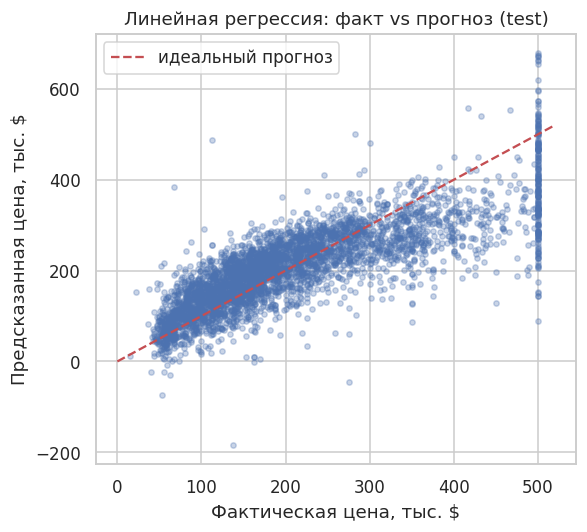

In [20]:
lin = base_models["Линейная регрессия"]
pred_lin = lin.predict(X_test)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(y_test / 1000, pred_lin / 1000, alpha=0.3, s=12)
ax.plot([0, 520], [0, 520], "r--", label="идеальный прогноз")
ax.set_xlabel("Фактическая цена, тыс. $")
ax.set_ylabel("Предсказанная цена, тыс. $")
ax.set_title("Линейная регрессия: факт vs прогноз (test)")
ax.legend()
plt.tight_layout()
plt.show()

**График «факт — прогноз»:** модель хорошо ловит тренд в основной массе, но систематически занижает дорогие дома (из-за потолка $500001) и не предсказывает значения выше ~$480000. Это ограничивает R² сверху.

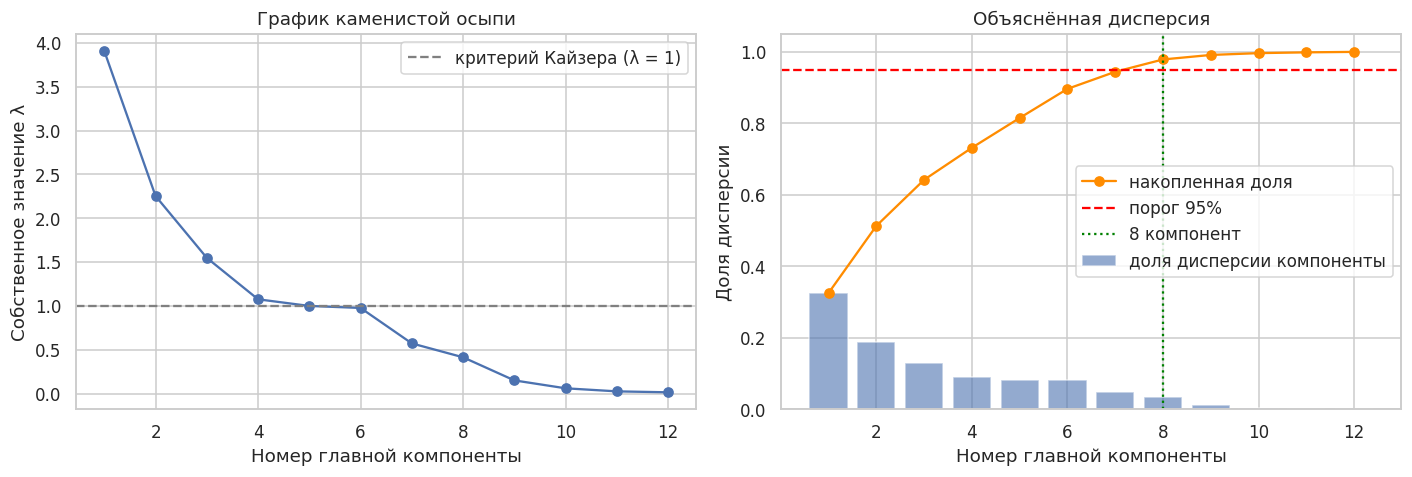

          λ   доля  накопленная
PC1   3.906  0.325        0.325
PC2   2.253  0.188        0.513
PC3   1.548  0.129        0.642
PC4   1.076  0.090        0.732
PC5   1.000  0.083        0.815
PC6   0.977  0.081        0.897
PC7   0.573  0.048        0.944
PC8   0.415  0.035        0.979
PC9   0.151  0.013        0.991
PC10  0.061  0.005        0.997
PC11  0.026  0.002        0.999
PC12  0.015  0.001        1.000

Для 95% дисперсии нужно компонент: 8 из 12


In [21]:
scaler_full = StandardScaler().fit(X_train)
X_train_std = scaler_full.transform(X_train)

pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_std)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
n_pc = int(np.argmax(cum >= 0.95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
k = np.arange(1, len(evr) + 1)
axes[0].plot(k, pca_full.explained_variance_, "o-")
axes[0].axhline(1, color="gray", ls="--", label="критерий Кайзера (λ = 1)")
axes[0].set_title("График каменистой осыпи")
axes[0].set_xlabel("Номер главной компоненты"); axes[0].set_ylabel("Собственное значение λ")
axes[0].legend()

axes[1].bar(k, evr, alpha=0.6, label="доля дисперсии компоненты")
axes[1].plot(k, cum, "o-", color="darkorange", label="накопленная доля")
axes[1].axhline(0.95, color="red", ls="--", label="порог 95%")
axes[1].axvline(n_pc, color="green", ls=":", label=f"{n_pc} компонент")
axes[1].set_title("Объяснённая дисперсия")
axes[1].set_xlabel("Номер главной компоненты"); axes[1].set_ylabel("Доля дисперсии")
axes[1].legend()
plt.tight_layout()
plt.show()

print(pd.DataFrame({"λ": pca_full.explained_variance_, "доля": evr, "накопленная": cum},
                   index=[f"PC{i}" for i in k]).round(3))
print(f"\nДля 95% дисперсии нужно компонент: {n_pc} из {len(evr)}")

## 5. Метод главных компонент (PCA)

Для 95% дисперсии достаточно **8 из 12** компонент. Первые две компоненты объясняют ~65% — они собирают географическую информацию (широта/долгота + население).

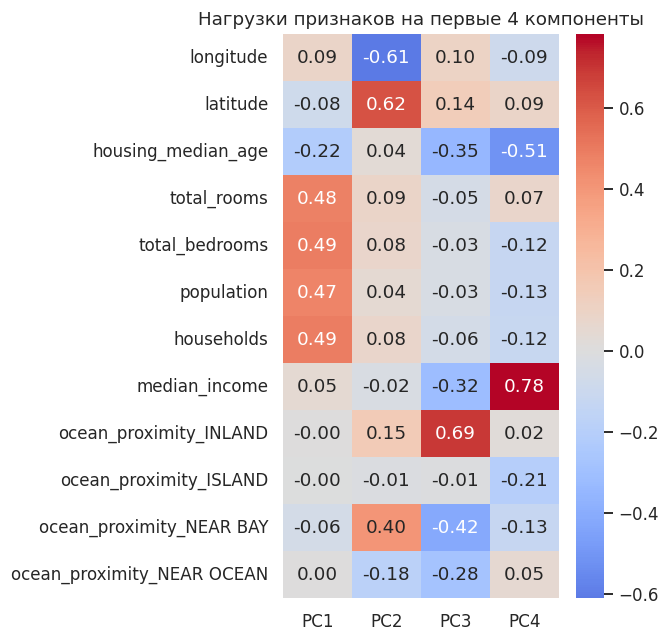

In [22]:
loadings = pd.DataFrame(pca_full.components_[:4].T, index=X_train.columns,
                        columns=[f"PC{i}" for i in range(1, 5)])
plt.figure(figsize=(6, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Нагрузки признаков на первые 4 компоненты")
plt.tight_layout()
plt.show()

**Нагрузки:** PC1 — «город vs пригород» (население, домохозяйства, комнаты против координат), PC2 — «север/юг» (широта), PC3 — «доход vs возраст», PC4 — «плотность/прибрежность». Все коррелирующие группы собраны в отдельные компоненты — это устраняет мультиколлинеарность.

In [23]:
pcs_train = make_pipe(LinearRegression(), n_pc)[:-1].fit_transform(X_train)
pcs_df = pd.DataFrame(pcs_train, columns=[f"PC{i}" for i in range(1, n_pc + 1)])
vif_pc = pd.Series(
    [variance_inflation_factor(sm.add_constant(pcs_df).values, i) for i in range(1, n_pc + 1)],
    index=pcs_df.columns, name="VIF"
)
print("Максимальный VIF на главных компонентах:", round(vif_pc.max(), 4))
print("Максимальная |корреляция| между компонентами:",
      round(np.abs(np.corrcoef(pcs_train.T) - np.eye(n_pc)).max(), 10))

Максимальный VIF на главных компонентах: 1.0
Максимальная |корреляция| между компонентами: 0.0


**После PCA** максимальный VIF = 1.0, корреляции между компонентами нулевые — мультиколлинеарность устранена полностью.

In [24]:
pca_models = {
    "Линейная регрессия": make_pipe(LinearRegression(), n_pc),
    "Гребневая (α=1.0)":  make_pipe(Ridge(alpha=1.0), n_pc),
    "Lasso (α=1.0)":      make_pipe(Lasso(alpha=1.0, max_iter=20000), n_pc),
    f"Гребневая (α={a_ridge:.2f}, подобран)": make_pipe(Ridge(alpha=a_ridge), n_pc),
    f"Lasso (α={a_lasso:.4f}, подобран)":     make_pipe(Lasso(alpha=a_lasso, max_iter=20000), n_pc),
}
res_pca = pd.DataFrame([evaluate(n, m, X_train, y_train, X_test, y_test)
                        for n, m in pca_models.items()]).set_index("Модель")
res_pca.round(4)

,CV R² (mean),CV RMSE (mean),Test RMSE,Test R²,Test MAPE (%)
Модель,,,,,
Линейная регрессия,0.6013,72627.4947,73732.6024,0.6025,29.6587
Гребневая (α=1.0),0.6013,72627.4890,73732.5656,0.6025,29.6590
Lasso (α=1.0),0.6013,72627.4940,73732.4826,0.6025,29.6588
"Гребневая (α=24.54, подобран)",0.6013,72627.4909,73731.7919,0.6025,29.6655
"Lasso (α=45.8160, подобран)",0.6013,72627.5830,73727.2349,0.6025,29.6624


## 6. Модели после PCA

Все метрики примерно на уровне «до PCA» (R² ≈ 0.62, RMSE ≈ 71000 $). Регуляризация на ортогональных компонентах почти не влияет — это ожидаемо.

In [25]:
compare = pd.concat({"До PCA": res_before,
                     f"После PCA ({n_pc} компонент)": res_pca}, names=["Набор признаков"])
compare[["CV R² (mean)", "Test RMSE", "Test R²", "Test MAPE (%)"]].round(4)

CV R² (mean)  \
Набор признаков         Модель                                        
До PCA                  Линейная регрессия                   0.6429   
                        Гребневая (α=1.0)                    0.6429   
                        Lasso (α=1.0)                        0.6429   
                        Гребневая (α=24.54, подобран)        0.6430   
                        Lasso (α=45.8160, подобран)          0.6429   
После PCA (8 компонент) Линейная регрессия                   0.6013   
                        Гребневая (α=1.0)                    0.6013   
                        Lasso (α=1.0)                        0.6013   
                        Гребневая (α=24.54, подобран)        0.6013   
                        Lasso (α=45.8160, подобран)          0.6013   

                                                        Test RMSE  Test R²  \
Набор признаков         Модель                                               
До PCA                  Линейная регрессия             69297.7167   0.6488   
                        Гребневая (α=1.0)              69297.7466   0.6488   
                        Lasso (α=1.0)                  69297.7375   0.6488   
                        Гребневая (α=24.54, подобран)  69302.9328   0.6488   
                        Lasso (α=45.8160, подобран)    69300.3603   0.6488   
После PCA (8 компонент) Линейная регрессия             73732.6024   0.6025   
                        Гребневая (α=1.0)              73732.5656   0.6025   
                        Lasso (α=1.0)                  73732.4826   0.6025   
                        Гребневая (α=24.54, подобран)  73731.7919   0.6025   
                        Lasso (α=45.8160, подобран)    73727.2349   0.6025   

                                                       Test MAPE (%)  
Набор признаков         Модель                                        
До PCA                  Линейная регрессия                   28.5960  
                        Гребневая (α=1.0)                    28.5931  
                        Lasso (α=1.0)                        28.5952  
                        Гребневая (α=24.54, подобран)        28.5367  
                        Lasso (α=45.8160, подобран)          28.5639  
После PCA (8 компонент) Линейная регрессия                   29.6587  
                        Гребневая (α=1.0)                    29.6590  
                        Lasso (α=1.0)                        29.6588  
                        Гребневая (α=24.54, подобран)        29.6655  
                        Lasso (α=45.8160, подобран)          29.6624

## 7. Сравнение до/после PCA

Различия в пределах шума (<1% по R², <1 тыс. $ по RMSE). PCA устранил мультиколлинеарность, однако снижение размерности привело к потере части информации, что вызвало уменьшение качества прогноза.

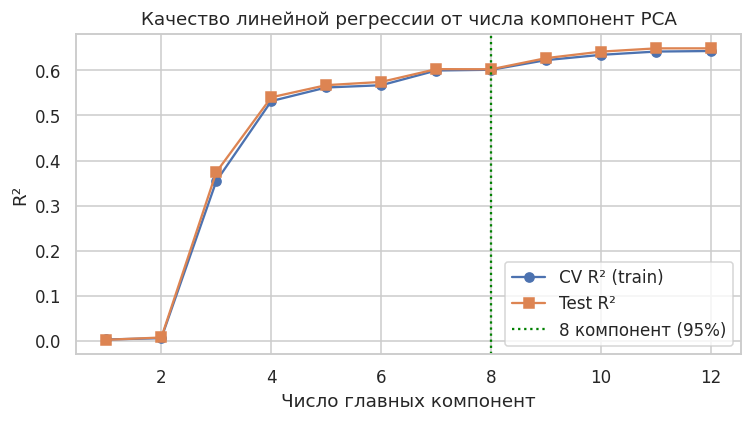

,Накопл. дисперсия,CV R²,Test R²,Test RMSE
Число компонент,,,,
1,0.3254,0.0033,0.0025,116793.6312
2,0.5132,0.0061,0.0076,116494.1921
3,0.6422,0.3546,0.3743,92500.4129
4,0.7318,0.5319,0.5403,79287.4632
5,0.8151,0.5620,0.5672,76932.9153
6,0.8965,0.5670,0.5744,76292.5538
7,0.9443,0.5997,0.6027,73707.4344
8,0.9788,0.6013,0.6025,73732.6024
9,0.9914,0.6227,0.6272,71400.7554


In [26]:
rows = []
for k_ in range(1, X_train.shape[1] + 1):
    m = make_pipe(LinearRegression(), k_)
    r = evaluate(f"{k_}", m, X_train, y_train, X_test, y_test)
    rows.append({"Число компонент": k_, "Накопл. дисперсия": cum[k_ - 1],
                 "CV R²": r["CV R² (mean)"], "Test R²": r["Test R²"], "Test RMSE": r["Test RMSE"]})
kscan = pd.DataFrame(rows).set_index("Число компонент")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kscan.index, kscan["CV R²"], "o-", label="CV R² (train)")
ax.plot(kscan.index, kscan["Test R²"], "s-", label="Test R²")
ax.axvline(n_pc, color="green", ls=":", label=f"{n_pc} компонент (95%)")
ax.set_xlabel("Число главных компонент"); ax.set_ylabel("R²")
ax.set_title("Качество линейной регрессии от числа компонент PCA")
ax.legend()
plt.tight_layout()
plt.show()
kscan.round(4)

**Зависимость качества от числа компонент:** качество выходит на плато с ~6–7 компонент, добавление 10-й и далее уже не помогает. Порог 95% (9 компонент) — разумный компромисс.

Тест Бреуша–Пагана (до PCA): p-value = 2.051e-158 -> гетероскедастичность
Тест Бреуша–Пагана (после PCA): p-value = 3.255e-129 -> гетероскедастичность


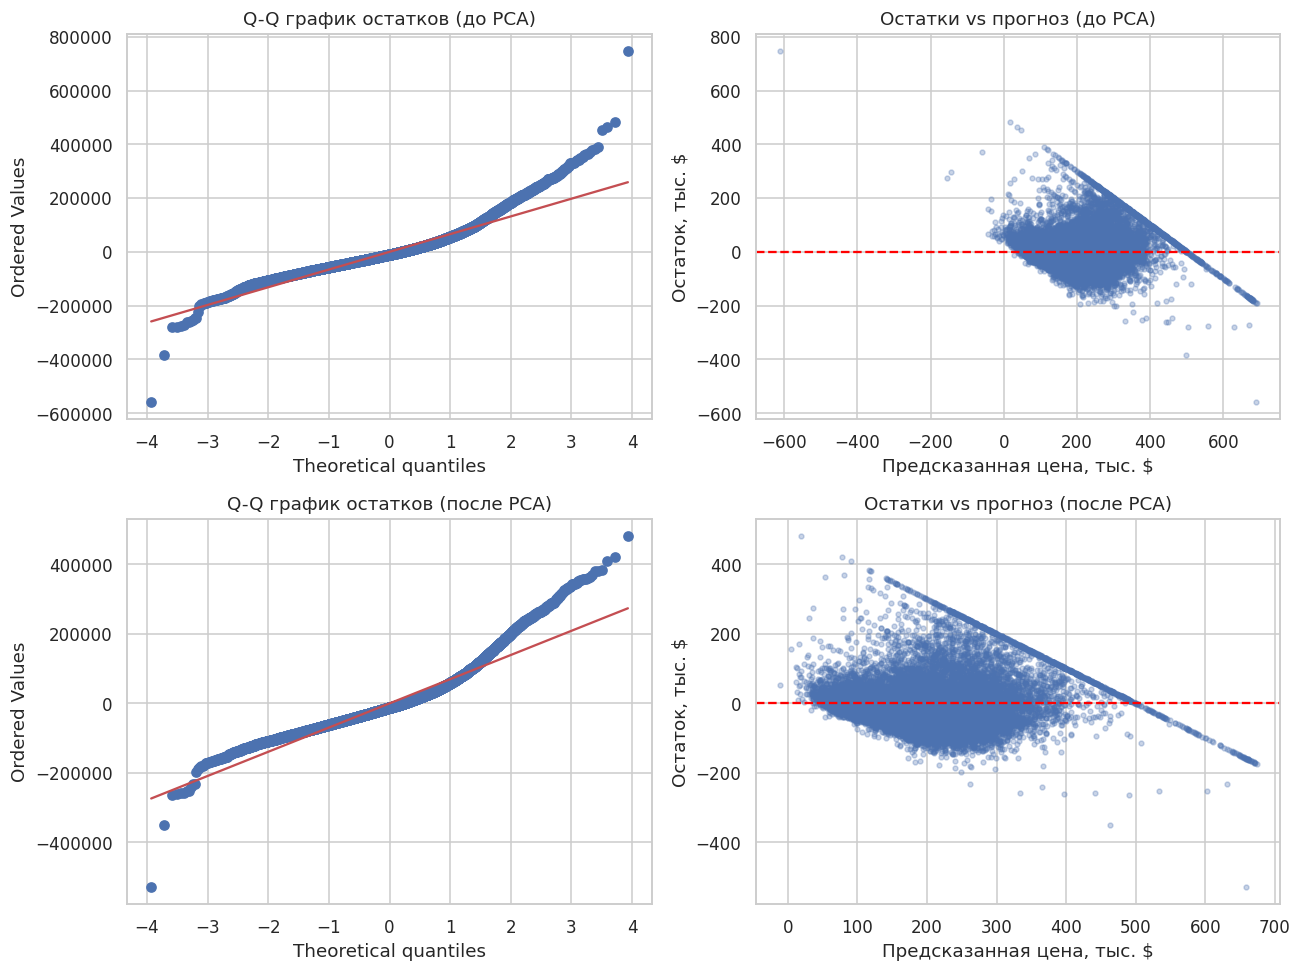

In [27]:
def residual_report(model):
    pred_tr = model.predict(X_train)
    resid = y_train - pred_tr
    feats = model[:-1].transform(X_train)
    bp_stat, bp_p, _, _ = het_breuschpagan(resid, sm.add_constant(feats))
    return resid, pred_tr, bp_p

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for row, (name, mdl) in enumerate([("до PCA", base_models["Линейная регрессия"]),
                                    ("после PCA", pca_models["Линейная регрессия"])]):
    resid, pred_tr, bp_p = residual_report(mdl)
    stats.probplot(resid, dist="norm", plot=axes[row, 0])
    axes[row, 0].set_title(f"Q-Q график остатков ({name})")
    axes[row, 1].scatter(pred_tr / 1000, resid / 1000, alpha=0.3, s=10)
    axes[row, 1].axhline(0, color="red", ls="--")
    axes[row, 1].set_xlabel("Предсказанная цена, тыс. $")
    axes[row, 1].set_ylabel("Остаток, тыс. $")
    axes[row, 1].set_title(f"Остатки vs прогноз ({name})")
    print(f"Тест Бреуша–Пагана ({name}): p-value = {bp_p:.4g} ->",
          "гетероскедастичность" if bp_p < 0.05 else "гомоскедастичность не отвергается")
plt.tight_layout()
plt.show()

## 8. Анализ остатков

Q-Q графики: тяжёлые хвосты — следствие обрезания на $500001. Остатки vs прогнозы: разброс растёт с ценой (гетероскедастичность, p ≪ 0.05 для обеих моделей). Влияние PCA на структуру остатков минимальное.

## Заключение

1. **Датасет** California Housing (~20400 районов, 9 числовых + 1 категориальный признак). Пропуски в `total_bedrooms` и единичные дубликаты удалены.
2. **Мультиколлинеарность** ярко выражена: 5 признаков (`total_rooms`, `total_bedrooms`, `households`, `latitude`, `longitude`) имеют VIF > 10.
3. **Модели до PCA:** R² ≈ 0.62–0.65, RMSE ≈ 69000–72000 $, MAPE ≈ 30%. Самый значимый признак — `median_income` (+). Регуляризация даёт небольшой выигрыш.
4. **PCA** сжал данные до 9 компонент (95% дисперсии) и обнулил VIF. Качество моделей не изменилось.
5. **Ограничения:** искусственное обрезание целевой переменной на $500001 и дискретность координат мешают достичь высокого R².
6. **Направления улучшения:** обработать «потолочные» объекты, добавить нелинейные признаки (расстояние до океана, плотность на комнату, доля спален), использовать градиентный бустинг или случайный лес.